#

FURTHER EDA - and KDE

In [2]:
#import the libraries -Data manipulation

import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Make plots look nicer
sns.set_theme(style="whitegrid")

# Show plots in notebook
%matplotlib inline

In [3]:
# read in the df

model_df_binary = pd.read_parquet("../data/model_df_binary.parquet")

In [4]:
print(model_df_binary.columns.tolist())

['crime_id', 'month', 'reported_by', 'longitude', 'latitude', 'location', 'lsoa_code', 'lsoa_name', 'crime_type', 'last_outcome_category', 'outcome_binary', 'employ_score_rate', 'income_score_rate', 'living_environment_score', 'barriers_score']


In [ ]:
# prepare for a sankey diagram - first create the groups/list

mapping = {
    "Investigation complete; no suspect identified": "Unresolved",
    "Unable to prosecute suspect": "Unresolved",

    "Local resolution": "Resolved",
    "Offender given a caution": "Resolved",
    "Action to be taken by another organisation": "Resolved",
    "Further investigation is not in the public interest": "Resolved",
    "Formal action is not in the public interest": "Resolved",
    "Suspect charged as part of another case": "Resolved",
    "Offender given a drugs possession warning": "Resolved"
}

In [18]:
# count of each category mapped

counts = (
    model_df_binary["last_outcome_category"]
    .value_counts()
    .reset_index()
)

counts.columns = ["Category", "Count"]

counts["Binary"] = counts["Category"].map(mapping)

print(mapping)

{'Investigation complete; no suspect identified': 'Unresolved', 'Unable to prosecute suspect': 'Unresolved', 'Local resolution': 'Resolved', 'Offender given a caution': 'Resolved', 'Action to be taken by another organisation': 'Resolved', 'Further investigation is not in the public interest': 'Resolved', 'Formal action is not in the public interest': 'Resolved', 'Suspect charged as part of another case': 'Resolved', 'Offender given a drugs possession warning': 'Resolved'}


In [22]:
# SANKEY DIAGRAM to show how the binary category was mapped to resolved/unresolved

import plotly.graph_objects as go

ModuleNotFoundError: No module named 'plotly'

In [ ]:
import plotly.graph_objects as go

# Nodes
left_nodes = counts["Category"].tolist()
right_nodes = ["Resolved", "Unresolved"]

labels = left_nodes + right_nodes

# Source indices
source = list(range(len(left_nodes)))

# Target indices
target = [
    labels.index(binary)
    for binary in counts["Binary"]
]

values = counts["Count"].tolist()

fig = go.Figure(data=[go.Sankey(

    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),

    link=dict(
        source=source,
        target=target,
        value=values
    )

)])

fig.update_layout(
    title_text="Collapsing Original Outcome Categories into Binary Outcome",
    font_size=11,
    width=1000,
    height=650
)

fig.show()

<Axes: xlabel='outcome_binary', ylabel='count'>

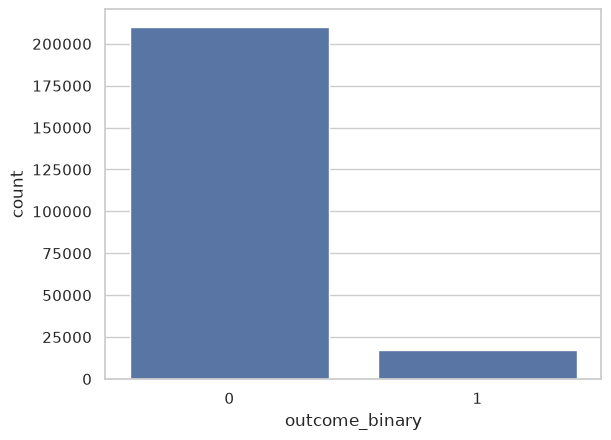

In [5]:
# more EDA on target or outcome variable - explore its distribution

sns.countplot(data=model_df_binary, x='outcome_binary')

binary outcome class shows significant class imbalance - need to manage this

In [6]:
model_df_binary['crime_type'].value_counts()

crime_type
Violence and sexual offences    108801
Public order                     21197
Criminal damage and arson        18690
Other theft                      17715
Vehicle crime                    14551
Shoplifting                      14422
Burglary                         12606
Other crime                       6159
Drugs                             5802
Robbery                           2912
Theft from the person             2217
Bicycle theft                     1488
Possession of weapons              998
Name: count, dtype: int64

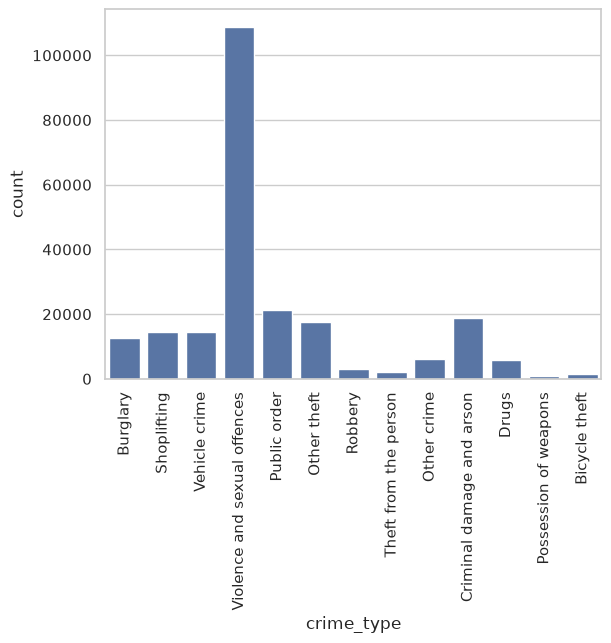

In [7]:
sns.countplot(data=model_df_binary, x='crime_type')
plt.xticks(rotation=90)
plt.show()

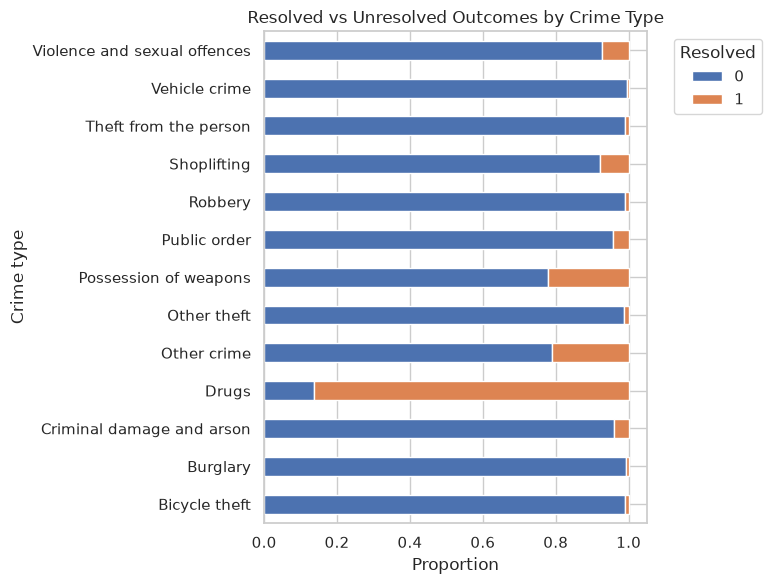

In [8]:
# which crimes are more likely to be resolved


ct = pd.crosstab(
    model_df_binary['crime_type'],
    model_df_binary['outcome_binary'],
    normalize='index'
)

ct.plot(kind='barh', stacked=True, figsize=(8, 6))
plt.xlabel('Proportion')
plt.ylabel('Crime type')
plt.title('Resolved vs Unresolved Outcomes by Crime Type')
plt.legend(title='Resolved', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Axes: xlabel='income_score_rate', ylabel='Count'>

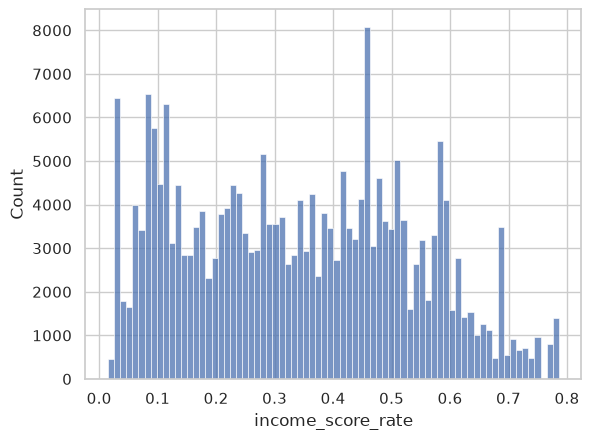

In [9]:
# Deprivation Analysis

sns.histplot(model_df_binary['income_score_rate'])


<Axes: xlabel='employ_score_rate', ylabel='Count'>

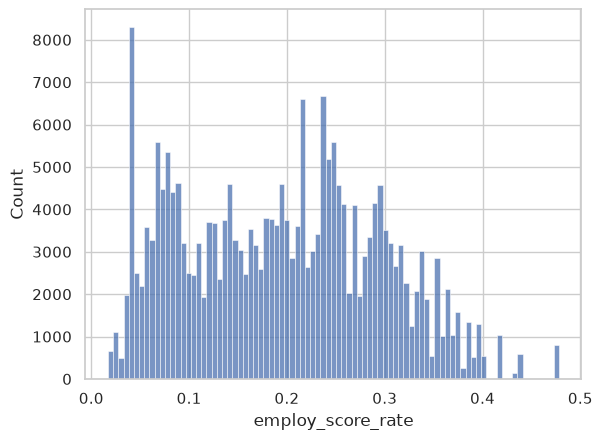

In [10]:
sns.histplot(model_df_binary['employ_score_rate'])

In [11]:
# summary stats and data overview



dataset_summary = pd.DataFrame({
    "Characteristic": [
        "Number of observations",
        "Total variables",
        "Numeric variables",
        "Categorical variables",
        "Missing values",
        "Duplicate rows",
        "Binary target classes"
    ],
    "Value": [
        len(model_df_binary),
        model_df_binary.shape[1],
        model_df_binary.select_dtypes(include=np.number).shape[1],
        model_df_binary.select_dtypes(exclude=np.number).shape[1],
        model_df_binary.isnull().sum().sum(),
        model_df_binary.duplicated().sum(),
        model_df_binary["outcome_binary"].nunique()
    ]
})

# Add commas to large numbers
dataset_summary["Value"] = dataset_summary["Value"].apply(
    lambda x: f"{x:,}" if isinstance(x, (int, np.integer)) else x
)

# Display nicely
dataset_summary.style.hide(axis="index").set_caption(
    "model_df_binary Data Overview"
)

Characteristic,Value
Number of observations,"227,558"
Total variables,15
Numeric variables,7
Categorical variables,8
Missing values,0
Duplicate rows,0
Binary target classes,2


# correlation heat map using Pearsons correlation coefficient

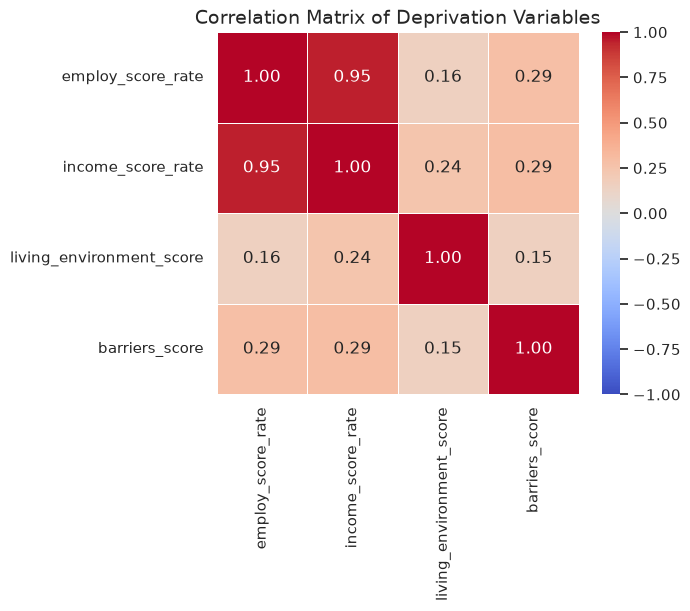

In [12]:
# correlation heat map 


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select the variables for the heatmap
corr_df = model_df_binary[[
    "employ_score_rate",
    "income_score_rate",
    "living_environment_score",
    "barriers_score"
]]

# Calculate the correlation matrix
corr_matrix = corr_df.corr()

# Create the heatmap
plt.figure(figsize=(7,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Deprivation Variables", fontsize=14)
plt.tight_layout()

plt.show()

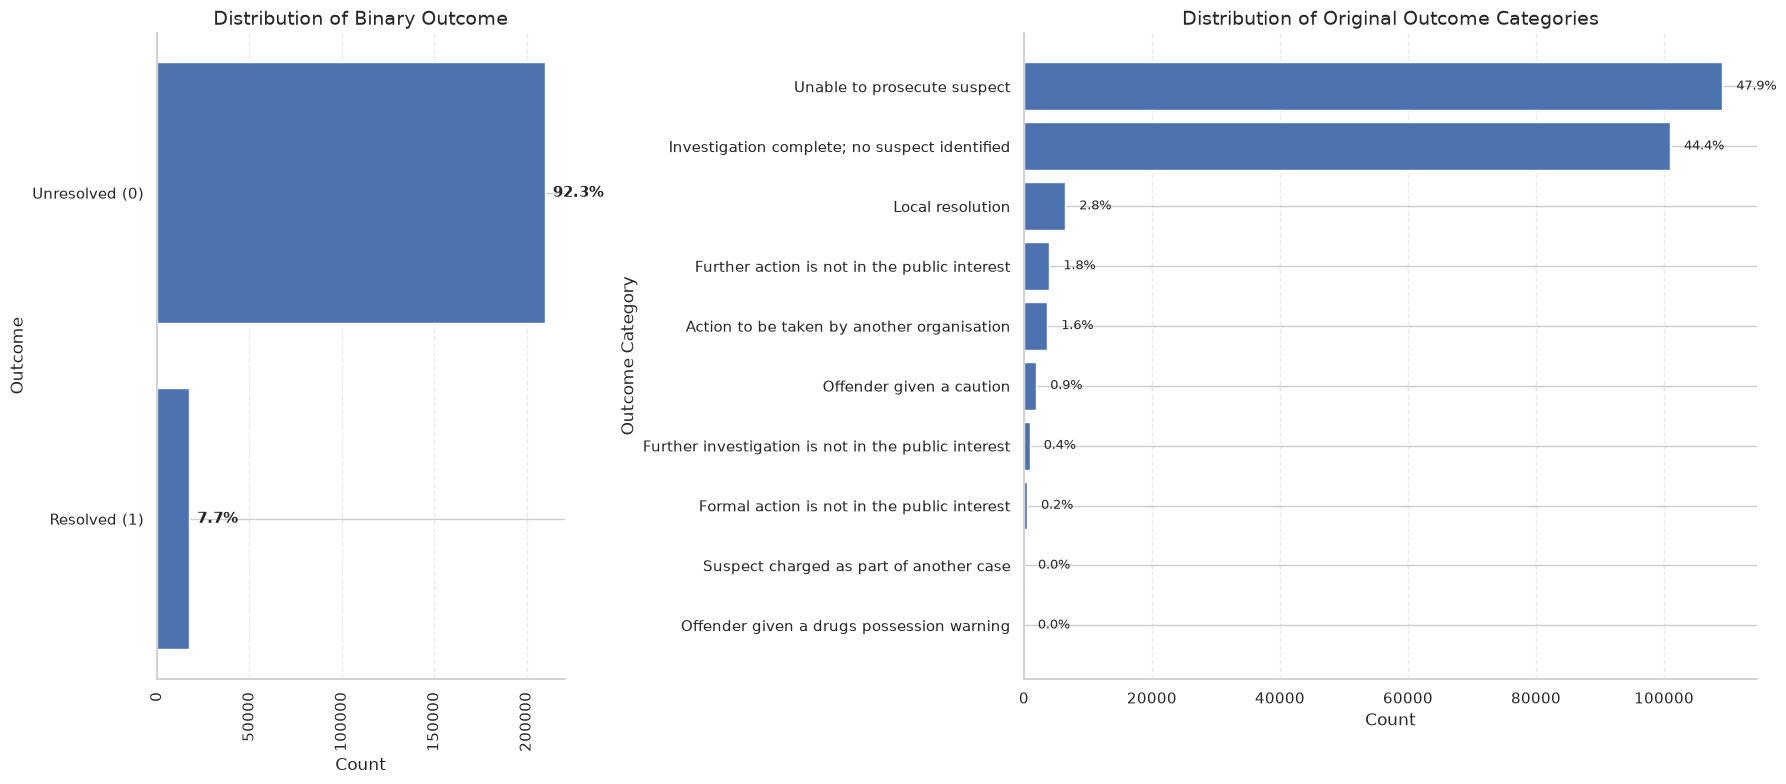

In [ ]:

# BAR CHARTS OF THE OUTCOME CATEGORIES - both of them

# Binary outcome counts and percentages
binary_counts = (
    model_df_binary["outcome_binary"]
    .value_counts()
    .sort_index()
)

binary_percent = (
    model_df_binary["outcome_binary"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

binary_labels = [
    "Unresolved (0)",
    "Resolved (1)"
]

# Original outcome counts and percentages
multi_counts = model_df_binary["last_outcome_category"].value_counts()

multi_percent = (
    model_df_binary["last_outcome_category"]
    .value_counts(normalize=True) * 100
)

# -----------------------------------
# Create figure
# -----------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8),
    gridspec_kw={"width_ratios": [1, 1.8]}
)

# ===================================
# Binary Outcome
# ===================================

bars = axes[0].barh(
    binary_labels,
    binary_counts.values,
    color="#4C72B0"
)

axes[0].set_title("Distribution of Binary Outcome", fontsize=14)
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Outcome")

axes[0].invert_yaxis()

# Rotate count tick labels vertically
axes[0].tick_params(axis='x', labelrotation=90)

# Add grid
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# Remove unnecessary borders
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

offset = binary_counts.max() * 0.02

for bar, pct in zip(bars, binary_percent):
    axes[0].text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# ===================================
# Original Outcome Categories
# ===================================

bars = axes[1].barh(
    multi_counts.index,
    multi_counts.values,
    color="#4C72B0"
)

axes[1].set_title("Distribution of Original Outcome Categories", fontsize=14)
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Outcome Category")

axes[1].invert_yaxis()

axes[1].grid(axis="x", linestyle="--", alpha=0.4)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

offset = multi_counts.max() * 0.02

for bar, pct in zip(bars, multi_percent):
    axes[1].text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        va="center",
        fontsize=9
    )

# -----------------------------------
# Final formatting
# -----------------------------------

plt.tight_layout()

plt.savefig(
    "outcome_distributions_horizontal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

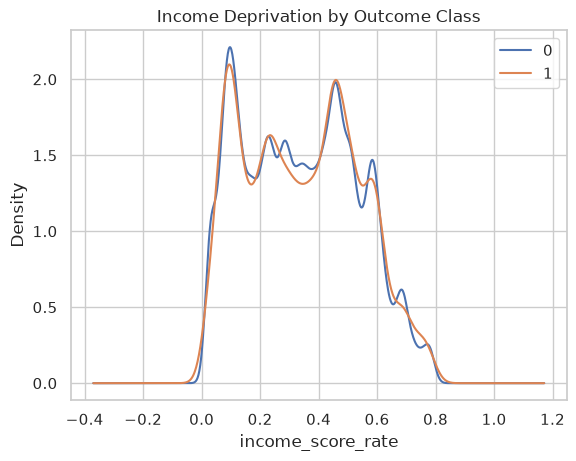

In [14]:
#KDE

for outcome in model_df_binary['outcome_binary'].unique():
    subset = model_df_binary[model_df_binary['outcome_binary'] == outcome]
    subset['income_score_rate'].plot(kind='kde', label=outcome)

plt.xlabel('income_score_rate')
plt.title('Income Deprivation by Outcome Class')
plt.legend()
plt.show()

KDE plot shows 